## HPA RNA Expression — `1_4_hpa_rna_celline.tsv`

Long-format RNA expression data from the Human Protein Atlas: 24 million rows (one per gene × cell line), covering 20,162 genes and 1,206 cell lines. Use `nTPM` (normalised TPM) for cross-line comparisons — it accounts for differences in gene length and sequencing depth. Always use `Gene` (Ensembl ID) as the primary key, never `Gene name`.

In [1]:
import __init__ as ini
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

In [2]:
%%time
df = pd.read_csv(f"{ini.gene_expression_dir}1_4_hpa_rna_celline.tsv", sep='\t')

CPU times: total: 11.4 s
Wall time: 11.6 s


## Basic structure check

Confirming shape, column types, and that IDs look sensible before going deeper.

In [3]:
df.shape

(24315372, 6)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24315372 entries, 0 to 24315371
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Gene       str    
 1   Gene name  str    
 2   Cell line  str    
 3   TPM        float64
 4   pTPM       float64
 5   nTPM       float64
dtypes: float64(3), str(3)
memory usage: 1.7 GB


In [5]:
df.head()

,Gene,Gene name,Cell line,TPM,pTPM,nTPM
0,ENSG00000000003,TSPAN6,143B,22.0,27.6,25.9
1,ENSG00000000003,TSPAN6,22Rv1,2.8,3.6,2.7
2,ENSG00000000003,TSPAN6,23132/87,6.2,7.5,7.5
3,ENSG00000000003,TSPAN6,253J,14.2,18.7,25.4
4,ENSG00000000003,TSPAN6,253J-BV,13.0,17.1,18.5


In [6]:
df["Gene"].nunique(), df["Gene"].unique()

(20162,
 <ArrowStringArray>
 ['ENSG00000000003', 'ENSG00000000005', 'ENSG00000000419', 'ENSG00000000457',
  'ENSG00000000460', 'ENSG00000000938', 'ENSG00000000971', 'ENSG00000001036',
  'ENSG00000001084', 'ENSG00000001167',
  ...
  'ENSG00000291302', 'ENSG00000291303', 'ENSG00000291307', 'ENSG00000291309',
  'ENSG00000291312', 'ENSG00000291313', 'ENSG00000291314', 'ENSG00000291315',
  'ENSG00000291316', 'ENSG00000291317']
 Length: 20162, dtype: str)

In [7]:
df["Gene name"].nunique(), df["Gene name"].unique()

(20151,
 <ArrowStringArray>
 [         'TSPAN6',            'TNMD',            'DPM1',           'SCYL3',
         'C1orf112',             'FGR',             'CFH',           'FUCA2',
             'GCLC',            'NFYA',
  ...
  'ENSG00000291302', 'ENSG00000291303',         'POLGARF',            'LY6S',
  'ENSG00000291312', 'ENSG00000291313', 'ENSG00000291314', 'ENSG00000291315',
  'ENSG00000291316',         'TMEM276']
 Length: 20151, dtype: str)

In [8]:
df["Cell line"].nunique(), df["Cell line"].unique()

(1206,
 <ArrowStringArray>
 [    '143B',    '22Rv1', '23132/87',     '253J',  '253J-BV', '42-MG-BA',
   '537-mel',     '5637',      '59M',  '624-mel',
  ...
      'YAPC',   'YD-10B',    'YD-15',    'YD-38',     'YD-8',    'YH-13',
     'YKG-1',    'YMB-1',  'ZR-75-1', 'ZR-75-30']
 Length: 1206, dtype: str)

In [9]:
df["Gene name"][df["Gene"]=="ENSG00000000003"]

0       TSPAN6
1       TSPAN6
2       TSPAN6
3       TSPAN6
4       TSPAN6
         ...  
1201    TSPAN6
1202    TSPAN6
1203    TSPAN6
1204    TSPAN6
1205    TSPAN6
Name: Gene name, Length: 1206, dtype: str

In [10]:
# 1. Create a simplified dataframe with just the unique pairs
unique_pairs = df[['Gene', 'Gene name']].drop_duplicates()

# 2. Count how many unique 'Gene' IDs exist for each 'Gene nam'
name_counts = unique_pairs.groupby('Gene name')['Gene'].transform('nunique')

# 3. Filter for Gene names that have more than 1 Ensembl ID associated with them
duplicated_names_df = unique_pairs[name_counts > 1].sort_values(by='Gene name')

duplicated_names_df

,Gene,Gene name
9141480,ENSG00000138641,HERC3
24174270,ENSG00000287542,HERC3
432954,ENSG00000015479,MATR3
23854680,ENSG00000280987,MATR3
6828372,ENSG00000125863,MKKS
24088644,ENSG00000285508,MKKS
24105528,ENSG00000285723,MKKS
22927266,ENSG00000255346,NOX5
24291252,ENSG00000290203,NOX5
18036936,ENSG00000183889,NPIPA9


In [11]:
print(duplicated_names_df)

                     Gene Gene name
9141480   ENSG00000138641     HERC3
24174270  ENSG00000287542     HERC3
432954    ENSG00000015479     MATR3
23854680  ENSG00000280987     MATR3
6828372   ENSG00000125863      MKKS
24088644  ENSG00000285508      MKKS
24105528  ENSG00000285723      MKKS
22927266  ENSG00000255346      NOX5
24291252  ENSG00000290203      NOX5
18036936  ENSG00000183889    NPIPA9
22161456  ENSG00000233024    NPIPA9
22857318  ENSG00000254093     PINX1
23074398  ENSG00000258724     PINX1
14569686  ENSG00000168255   POLR2J3
24081408  ENSG00000285437   POLR2J3
2590488   ENSG00000100033     PRODH
23717196  ENSG00000277196     PRODH
24034374  ENSG00000284770      TBCE
24060906  ENSG00000285053      TBCE
12120300  ENSG00000158427   TMSB15B
23391576  ENSG00000269226   TMSB15B


In [12]:
missing_names = df[df['Gene name'].isna()]['Gene'].nunique()
print(f"Number of Gene IDs missing a Gene Name: {missing_names}")

Number of Gene IDs missing a Gene Name: 0


## Gene name vs Ensembl ID consistency

Checking whether gene names are safe to use as identifiers — or whether some names map to multiple Ensembl IDs (which would cause silent errors in any groupby or merge).

**Finding:** 10 gene names each map to more than one Ensembl ID (HERC3, MATR3, MKKS, NOX5, NPIPA9, PINX1, POLR2J3, PRODH, TBCE, TMSB15B). These are alternative genomic loci and patches in GRCh38 — the same biological gene appears on both a primary chromosome and an alternate contig, each with its own Ensembl ID. **Always join and group by `Gene` (Ensembl ID), not `Gene name`.**

## Expression value distributions

Visualising the shape of TPM, pTPM, and nTPM to check for skew and outliers before any modelling.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

### Histograms (log-scaled)

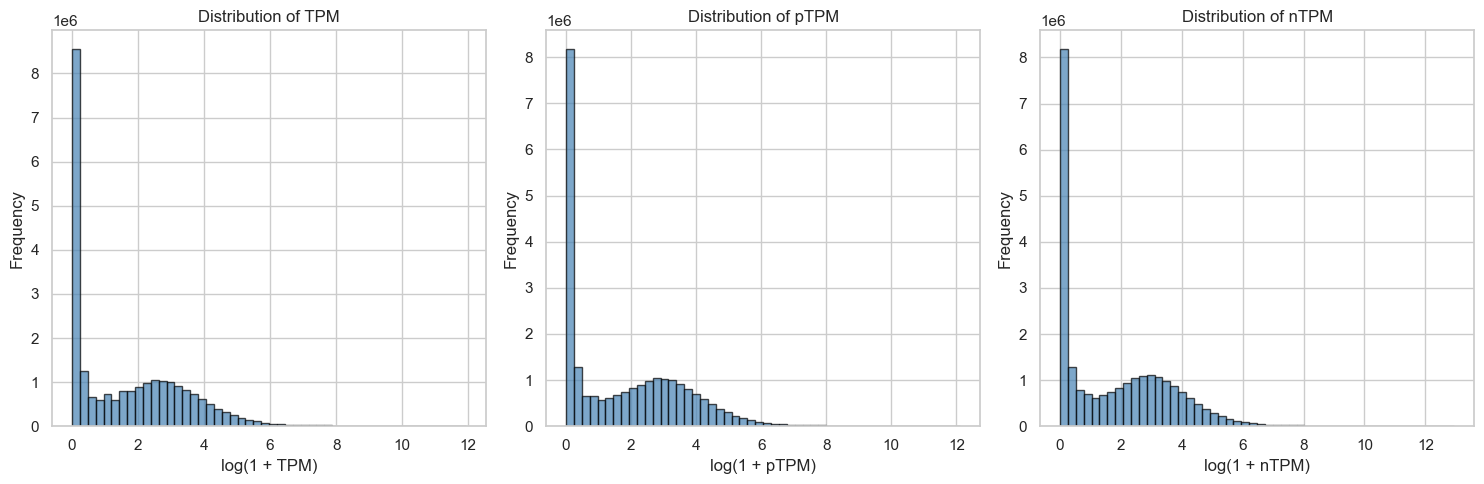

In [14]:
# List of your expression columns
tpm_columns = ['TPM', 'pTPM', 'nTPM']

# Create a layout with 1 row and 3 columns
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

for i, col in enumerate(tpm_columns):
    # Drop missing values and apply log(x+1) transformation for readability
    data = np.log1p(df[col].dropna())
    
    # Plot the histogram
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    
    # Labeling
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(f'log(1 + {col})')
    axes[i].set_ylabel('Frequency')

# Automatically adjust padding so titles/labels don't overlap
plt.tight_layout()

# Save the plot to a file
# plt.savefig('tpm_histograms.png')

### Boxplots — spread and outliers across TPM variants

C:\Users\ksstu\AppData\Local\Temp\ipykernel_8004\1385740295.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(data_to_plot, labels=['TPM', 'pTPM', 'nTPM'], patch_artist=True)


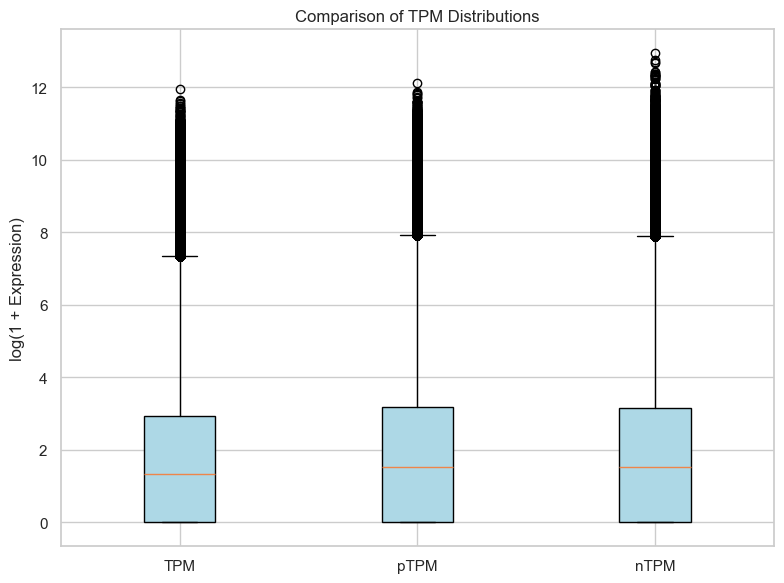

In [15]:
# Prepare log-transformed data for each column, removing NaNs
data_to_plot = [
    np.log1p(df['TPM'].dropna()),
    np.log1p(df['pTPM'].dropna()),
    np.log1p(df['nTPM'].dropna())
]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the boxplots
bplot = ax.boxplot(data_to_plot, labels=['TPM', 'pTPM', 'nTPM'], patch_artist=True)

# Add some color
for patch in bplot['boxes']:
    patch.set_facecolor('lightblue')

# Labeling
ax.set_title('Comparison of TPM Distributions')
ax.set_ylabel('log(1 + Expression)')

plt.tight_layout()

# Save the plot to a file
# plt.savefig('tpm_boxplots.png')

In [16]:
# Define the expression columns you want to check
tpm_columns = ['TPM', 'pTPM', 'nTPM']

# Create an empty list to store our calculations
zero_stats = []

for col in tpm_columns:
    # 1. Count how many exact 0.0 values exist
    zero_count = (df[col] == 0).sum()
    
    # 2. Calculate the percentage relative to the total number of rows
    # (Using len(df) assumes you want the percentage out of the entire dataset)
    total_rows = len(df)
    zero_percent = (zero_count / total_rows) * 100
    
    # Add to our list
    zero_stats.append({
        'Column': col,
        'Zero Count': zero_count,
        'Percentage of Zeros (%)': round(zero_percent, 2)
    })

# Create a clean dataframe to display the results
zero_summary_df = pd.DataFrame(zero_stats)

# Display the result
print("--- Zero Value Summary ---")
print(zero_summary_df.to_string(index=False))

--- Zero Value Summary ---
Column  Zero Count  Percentage of Zeros (%)
   TPM     6798598                    27.96
  pTPM     6409686                    26.36
  nTPM     6402047                    26.33


**Finding:** ~27% of TPM values and ~26% of pTPM/nTPM values are exactly zero — meaning the gene was not detected in that cell line. This is biologically normal; do not impute with mean. Consider a binary "expressed/not" flag or a detection-floor value in preprocessing.

### Per-gene variability across cell lines
Genes with high standard deviation in nTPM are the most informative for distinguishing cell lines from each other.

Computing per-gene stats... (may take ~30s on 24M rows)


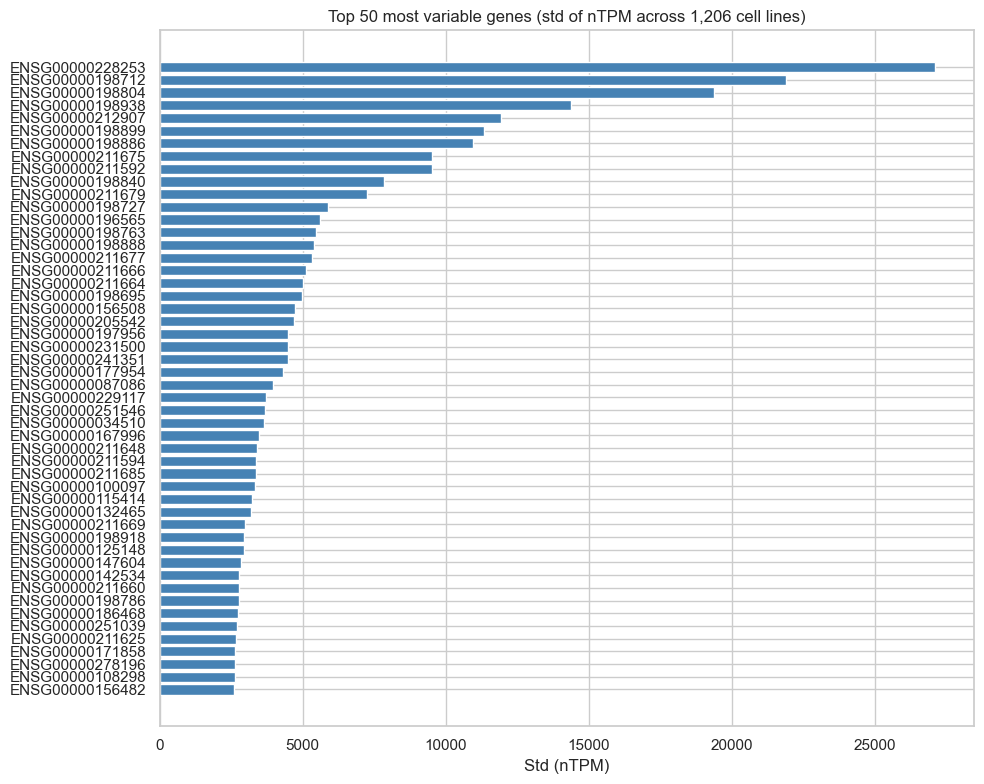

In [17]:
print("Computing per-gene stats... (may take ~30s on 24M rows)")
gene_stats = df.groupby("Gene")["nTPM"].agg(["mean", "std"]).reset_index()
gene_stats = gene_stats.sort_values("std", ascending=False)

top50_var = gene_stats.head(50)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top50_var["Gene"].iloc[::-1], top50_var["std"].iloc[::-1], color="steelblue")
ax.set_title("Top 50 most variable genes (std of nTPM across 1,206 cell lines)")
ax.set_xlabel("Std (nTPM)")
plt.tight_layout(); plt.show()


### Per-cell-line total expression
The sum of nTPM across all genes per cell line reflects overall transcriptional activity.

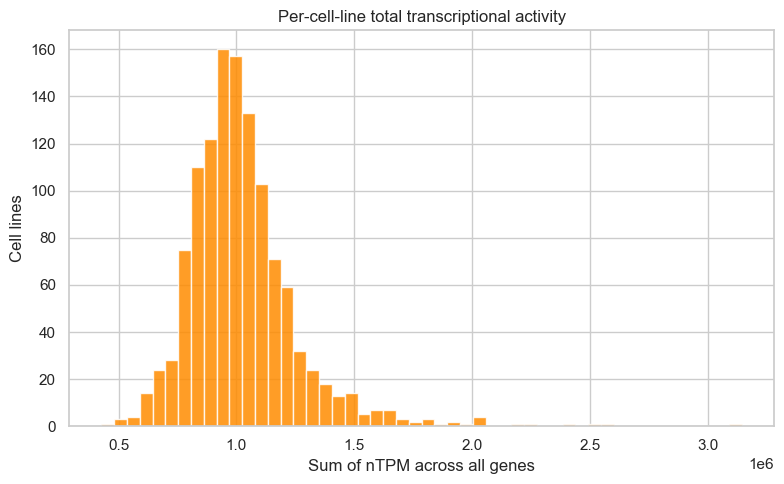

In [18]:
line_stats = df.groupby("Cell line")["nTPM"].agg(["sum", "mean"]).reset_index()
line_stats = line_stats.sort_values("sum", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(line_stats["sum"], bins=50, color="darkorange", edgecolor="white", alpha=0.85)
ax.set_xlabel("Sum of nTPM across all genes")
ax.set_ylabel("Cell lines")
ax.set_title("Per-cell-line total transcriptional activity")
plt.tight_layout(); plt.show()


### Top 20 most and least expressed genes
High mean-expression genes are housekeeping genes (always on). Low mean-expression genes are rarely expressed.

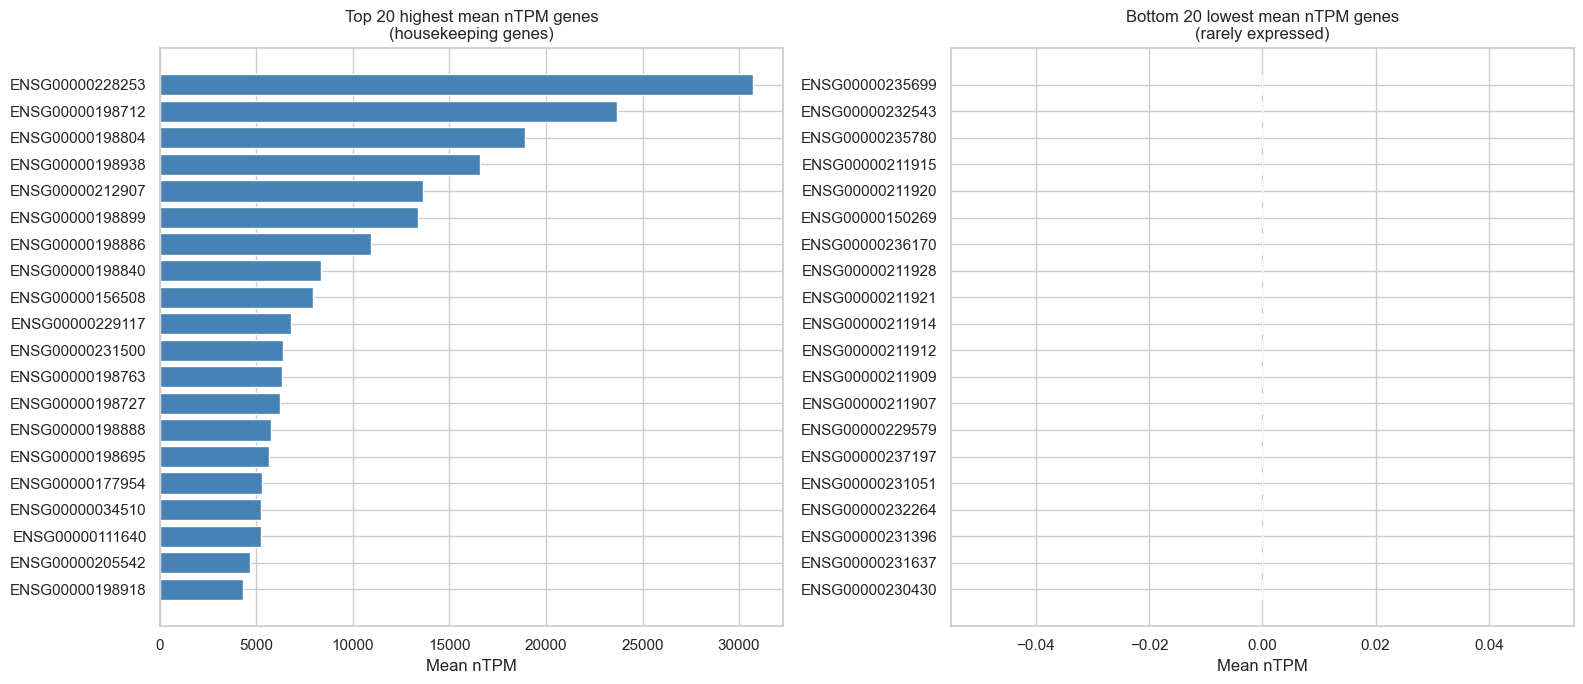

In [19]:
top20_expr = gene_stats.nlargest(20, "mean")
bot20_expr = gene_stats.nsmallest(20, "mean")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh(top20_expr["Gene"].iloc[::-1], top20_expr["mean"].iloc[::-1], color="steelblue")
axes[0].set_title("Top 20 highest mean nTPM genes\n(housekeeping genes)")
axes[0].set_xlabel("Mean nTPM")

axes[1].barh(bot20_expr["Gene"].iloc[::-1], bot20_expr["mean"].iloc[::-1], color="salmon")
axes[1].set_title("Bottom 20 lowest mean nTPM genes\n(rarely expressed)")
axes[1].set_xlabel("Mean nTPM")

plt.tight_layout(); plt.show()


### Expression heatmap — top 50 variable genes × 30 cell lines
A quick visual overview of which cell lines have distinctive expression patterns.

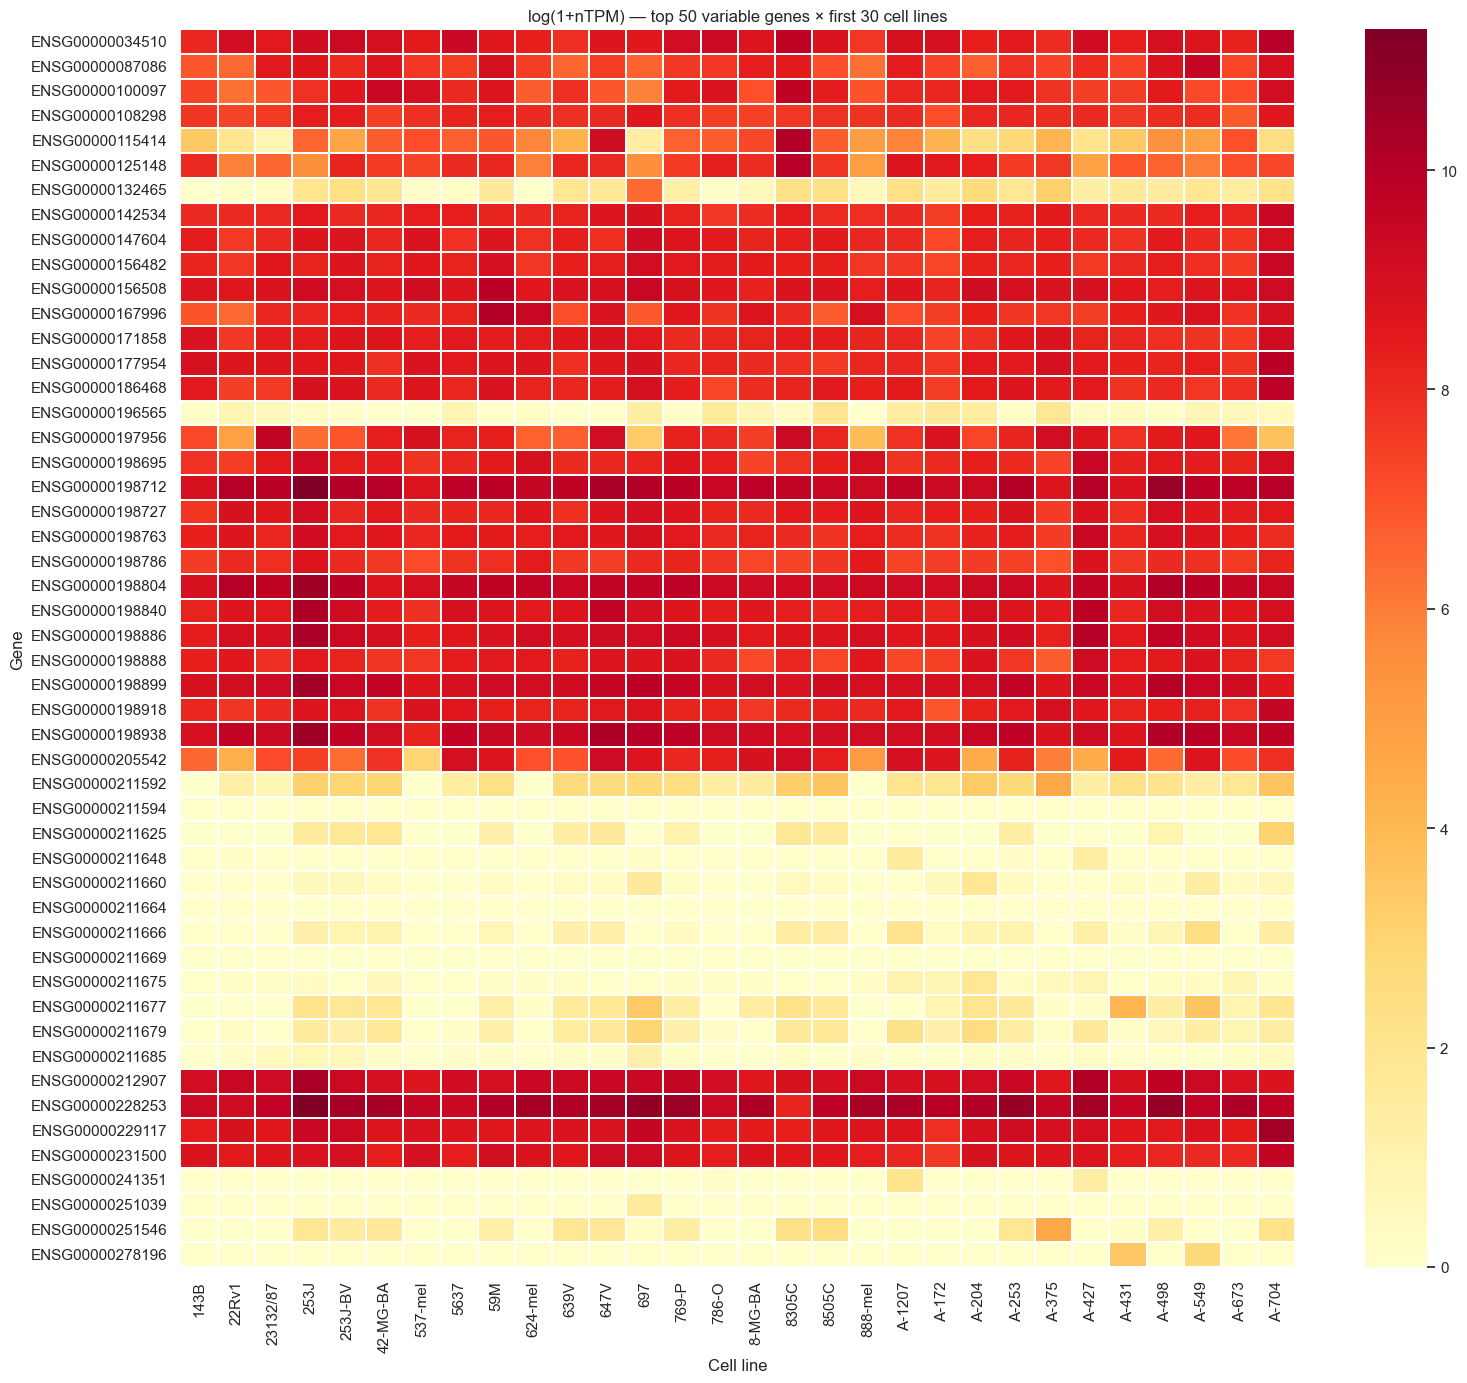

In [20]:
top50_genes = gene_stats.head(50)["Gene"].tolist()
sample_lines = df["Cell line"].unique()[:30]

heat_df = df[df["Gene"].isin(top50_genes) & df["Cell line"].isin(sample_lines)]
pivot = heat_df.pivot_table(index="Gene", columns="Cell line", values="nTPM", aggfunc="mean")

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(np.log1p(pivot), cmap="YlOrRd", ax=ax, xticklabels=True,
            yticklabels=True, linewidths=0.1)
ax.set_title("log(1+nTPM) — top 50 variable genes × first 30 cell lines")
plt.tight_layout(); plt.show()


### Correlation between TPM, pTPM, nTPM
All three metrics should be highly correlated; nTPM is preferred because it normalises for gene length.

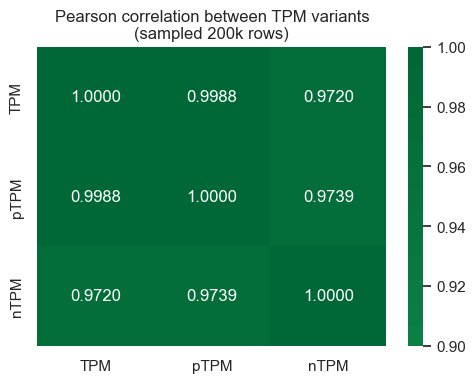

In [21]:
sample_df = df.sample(200_000, random_state=42)
corr_mat = sample_df[["TPM", "pTPM", "nTPM"]].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_mat, annot=True, fmt=".4f", cmap="RdYlGn", center=0,
            vmin=0.9, vmax=1.0, ax=ax)
ax.set_title("Pearson correlation between TPM variants\n(sampled 200k rows)")
plt.tight_layout(); plt.show()


### Key findings

In [22]:
print("=== HPA RNA Expression ===")
print(f"Total rows (gene × cell line): {len(df):,}")
print(f"Unique genes (Ensembl IDs)   : {df['Gene'].nunique()}")
print(f"Unique cell lines            : {df['Cell line'].nunique()}")
print(f"Most variable gene           : {gene_stats.iloc[0]['Gene']} (std={gene_stats.iloc[0]['std']:.2f})")
print(f"Most expressed gene (mean)   : {gene_stats.nlargest(1,'mean').iloc[0]['Gene']}")
print(f"~% nTPM zeros                : {(df['nTPM']==0).mean()*100:.1f}%")


=== HPA RNA Expression ===
Total rows (gene × cell line): 24,315,372


Unique genes (Ensembl IDs)   : 20162


Unique cell lines            : 1206
Most variable gene           : ENSG00000228253 (std=27116.31)
Most expressed gene (mean)   : ENSG00000228253
~% nTPM zeros                : 26.3%


## Join Analysis — how this table connects to the others

HPA RNA (df1) uses **free-text cell-line names** — the hardest ID system to join.
The path to DepMap's master catalogue is three hops long and each hop risks losing rows.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df1 | `Cell line` | df11 | `Cell line` | 1:1 expected | same HPA project; should be complete |
| df11 | `Cellosaurus ID` | df7 | `Accession (CVCL_xxxx)` | 1:1 | CVCL_ format |
| df7 | `Accession` = RRID | df9 | `RRID` | 1:1 | maps HPA → DepMap world |

**Why this matters biologically:** A cell line that falls off at any hop cannot be
used in a combined HPA + DepMap model. Understanding which cancer types drop out
tells us where the multi-omics pipeline has blind spots.


In [23]:
# ── A/B: Join coverage across three hops ────────────────────────────────────
df11_meta = pd.read_csv(ini.df11, sep="\t", usecols=["Cell line", "Cellosaurus ID"])
df7_ids   = pd.read_csv(ini.df7,  usecols=["Identifier (cell line name)", "Accession (CVCL_xxxx)"])
df9_ids   = pd.read_csv(ini.df9,  usecols=["DepMap_ID", "RRID", "lineage"])

hpa_lines   = set(df["Cell line"].dropna().unique())            # df1 already loaded
df11_lines  = set(df11_meta["Cell line"].dropna())
step1_match = hpa_lines & df11_lines
step1_lost  = hpa_lines - df11_lines

df11_cvcl   = set(df11_meta[df11_meta["Cell line"].isin(step1_match)]["Cellosaurus ID"].dropna())
df7_cvcl    = set(df7_ids["Accession (CVCL_xxxx)"].dropna())
step2_match = df11_cvcl & df7_cvcl
step2_lost  = df11_cvcl - df7_cvcl

df9_rrid    = set(df9_ids["RRID"].dropna())
step3_match = step2_match & df9_rrid
step3_lost  = step2_match - df9_rrid

print("=== df1 join path: Cell line → df11 → df7 → df9 ===")
print(f"Start : {len(hpa_lines):>6} HPA cell lines")
print(f"Hop 1 : {len(step1_match):>6} matched in df11   | lost: {len(step1_lost)}")
print(f"Hop 2 : {len(step2_match):>6} CVCL_ in df7      | lost: {len(step2_lost)}")
print(f"Hop 3 : {len(step3_match):>6} reach df9 (RRID)  | lost: {len(step3_lost)}")
print(f"\nOverall survival: {len(step3_match)/len(hpa_lines)*100:.1f}% of HPA lines reach df9")


=== df1 join path: Cell line → df11 → df7 → df9 ===
Start :   1206 HPA cell lines
Hop 1 :   1206 matched in df11   | lost: 0
Hop 2 :   1197 CVCL_ in df7      | lost: 1
Hop 3 :   1103 reach df9 (RRID)  | lost: 94

Overall survival: 91.5% of HPA lines reach df9


In [24]:
# ── C: Format consistency on 'Cell line' in df1 ─────────────────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


fmt_check(df["Cell line"], "Cell line (df1)")
print()

# Compare naming in df1 vs df11 — are they identical strings?
df11_cl = pd.read_csv(ini.df11, sep="\t", usecols=["Cell line"])["Cell line"]
df1_cl  = df["Cell line"].drop_duplicates()
case_mismatches = {
    n for n in (hpa_lines - df11_lines)
    if n.lower() in {x.lower() for x in df11_lines}
}
print(f"Case-only mismatches between df1 and df11 'Cell line': {len(case_mismatches)}")
if case_mismatches:
    print(f"  Examples: {list(case_mismatches)[:5]}")


Format check — Cell line (df1) (n=24315372 non-null, 0 NaN):
  Leading whitespace  : False


  Trailing whitespace : False
  Length range        : 2 – 41


  Duplicates          : 24314166



Case-only mismatches between df1 and df11 'Cell line': 0


### Biological implications of join losses

Rows lost at Hop 1 (df1 → df11) are HPA cell lines with no description entry — likely
data-quality gaps within the HPA project itself.

Rows surviving all three hops are the HPA lines that can participate in a combined
HPA + DepMap multi-omics analysis. Rows that fall off at Hop 3 have Cellosaurus
entries but were not included in DepMap's sequencing efforts — typically rarer
cancer types or less-studied cell lines.


In [25]:
# Biological: which lineages are in HPA but absent from DepMap?
# Lines that survived to df9 (have ModelID via RRID)
df9_hpa_subset = df9_ids[df9_ids["RRID"].isin(step3_match)]
df9_hpa_lineages = df9_hpa_subset["lineage"].value_counts()

# Lines that are in df1 but DON'T reach df9
lost_lines = hpa_lines - {
    r for _, row in df11_meta.iterrows()
    if row["Cellosaurus ID"] in step3_match
    for r in [row["Cell line"]]
}
print(f"HPA lines that DO reach df9       : {len(step3_match)}")
print(f"HPA lines that do NOT reach df9   : {len(hpa_lines) - len(step3_match)}")
print()
print("Lineage breakdown of HPA lines that DO reach df9 (top 10):")
print(df9_hpa_lineages.head(10).to_string())
print()
print("==> Joining df1 to df9 retains all major lineages if coverage is ~uniform.")
print("    Spotty coverage in a lineage = that cancer type under-represented in multi-omics.")


HPA lines that DO reach df9       : 1103
HPA lines that do NOT reach df9   : 103

Lineage breakdown of HPA lines that DO reach df9 (top 10):
lineage
lung                      214
blood                      89
lymphocyte                 72
central_nervous_system     66
breast                     62
colorectal                 58
ovary                      56
skin                       54
pancreas                   45
fibroblast                 39

==> Joining df1 to df9 retains all major lineages if coverage is ~uniform.
    Spotty coverage in a lineage = that cancer type under-represented in multi-omics.


## Join Analysis — how this table connects to the others

HPA RNA (df1) uses **free-text cell-line names** — the hardest ID system to join.
The path to DepMap's master catalogue is three hops long and each hop risks losing rows.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df1 | `Cell line` | df11 | `Cell line` | 1:1 expected | same HPA project; should be complete |
| df11 | `Cellosaurus ID` | df7 | `Accession (CVCL_xxxx)` | 1:1 | CVCL_ format |
| df7 | `Accession` = RRID | df9 | `RRID` | 1:1 | maps HPA → DepMap world |

**Why this matters biologically:** A cell line that falls off at any hop cannot be
used in a combined HPA + DepMap model. Understanding which cancer types drop out
tells us where the multi-omics pipeline has blind spots.


In [26]:
# ── A/B: Join coverage across three hops ────────────────────────────────────
df11_meta = pd.read_csv(ini.df11, sep="\t", usecols=["Cell line", "Cellosaurus ID"])
df7_ids   = pd.read_csv(ini.df7,  usecols=["Identifier (cell line name)", "Accession (CVCL_xxxx)"])
df9_ids   = pd.read_csv(ini.df9,  usecols=["DepMap_ID", "RRID", "lineage"])

hpa_lines   = set(df["Cell line"].dropna().unique())            # df1 already loaded
df11_lines  = set(df11_meta["Cell line"].dropna())
step1_match = hpa_lines & df11_lines
step1_lost  = hpa_lines - df11_lines

df11_cvcl   = set(df11_meta[df11_meta["Cell line"].isin(step1_match)]["Cellosaurus ID"].dropna())
df7_cvcl    = set(df7_ids["Accession (CVCL_xxxx)"].dropna())
step2_match = df11_cvcl & df7_cvcl
step2_lost  = df11_cvcl - df7_cvcl

df9_rrid    = set(df9_ids["RRID"].dropna())
step3_match = step2_match & df9_rrid
step3_lost  = step2_match - df9_rrid

print("=== df1 join path: Cell line → df11 → df7 → df9 ===")
print(f"Start : {len(hpa_lines):>6} HPA cell lines")
print(f"Hop 1 : {len(step1_match):>6} matched in df11   | lost: {len(step1_lost)}")
print(f"Hop 2 : {len(step2_match):>6} CVCL_ in df7      | lost: {len(step2_lost)}")
print(f"Hop 3 : {len(step3_match):>6} reach df9 (RRID)  | lost: {len(step3_lost)}")
print(f"\nOverall survival: {len(step3_match)/len(hpa_lines)*100:.1f}% of HPA lines reach df9")


=== df1 join path: Cell line → df11 → df7 → df9 ===
Start :   1206 HPA cell lines
Hop 1 :   1206 matched in df11   | lost: 0
Hop 2 :   1197 CVCL_ in df7      | lost: 1
Hop 3 :   1103 reach df9 (RRID)  | lost: 94

Overall survival: 91.5% of HPA lines reach df9


In [27]:
# ── C: Format consistency on 'Cell line' in df1 ─────────────────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


fmt_check(df["Cell line"], "Cell line (df1)")
print()

# Compare naming in df1 vs df11 — are they identical strings?
df11_cl = pd.read_csv(ini.df11, sep="\t", usecols=["Cell line"])["Cell line"]
df1_cl  = df["Cell line"].drop_duplicates()
case_mismatches = {
    n for n in (hpa_lines - df11_lines)
    if n.lower() in {x.lower() for x in df11_lines}
}
print(f"Case-only mismatches between df1 and df11 'Cell line': {len(case_mismatches)}")
if case_mismatches:
    print(f"  Examples: {list(case_mismatches)[:5]}")


Format check — Cell line (df1) (n=24315372 non-null, 0 NaN):
  Leading whitespace  : False


  Trailing whitespace : False
  Length range        : 2 – 41


  Duplicates          : 24314166



Case-only mismatches between df1 and df11 'Cell line': 0


### Biological implications of join losses

Rows lost at Hop 1 (df1 → df11) are HPA cell lines with no description entry — likely
data-quality gaps within the HPA project itself.

Rows surviving all three hops are the HPA lines that can participate in a combined
HPA + DepMap multi-omics analysis. Rows that fall off at Hop 3 have Cellosaurus
entries but were not included in DepMap's sequencing efforts — typically rarer
cancer types or less-studied cell lines.


In [28]:
# Biological: which lineages are in HPA but absent from DepMap?
# Lines that survived to df9 (have ModelID via RRID)
df9_hpa_subset = df9_ids[df9_ids["RRID"].isin(step3_match)]
df9_hpa_lineages = df9_hpa_subset["lineage"].value_counts()

# Lines that are in df1 but DON'T reach df9
lost_lines = hpa_lines - {
    r for _, row in df11_meta.iterrows()
    if row["Cellosaurus ID"] in step3_match
    for r in [row["Cell line"]]
}
print(f"HPA lines that DO reach df9       : {len(step3_match)}")
print(f"HPA lines that do NOT reach df9   : {len(hpa_lines) - len(step3_match)}")
print()
print("Lineage breakdown of HPA lines that DO reach df9 (top 10):")
print(df9_hpa_lineages.head(10).to_string())
print()
print("==> Joining df1 to df9 retains all major lineages if coverage is ~uniform.")
print("    Spotty coverage in a lineage = that cancer type under-represented in multi-omics.")


HPA lines that DO reach df9       : 1103
HPA lines that do NOT reach df9   : 103

Lineage breakdown of HPA lines that DO reach df9 (top 10):
lineage
lung                      214
blood                      89
lymphocyte                 72
central_nervous_system     66
breast                     62
colorectal                 58
ovary                      56
skin                       54
pancreas                   45
fibroblast                 39

==> Joining df1 to df9 retains all major lineages if coverage is ~uniform.
    Spotty coverage in a lineage = that cancer type under-represented in multi-omics.


## Deeper dive: per-lineage transcriptional activity

The base notebook already verified the symbol->Ensembl collisions and the ~27% zero
rate. The missing biological view is **per cancer type**: do some lineages run a
systematically higher total transcriptional output? We map each HPA cell line to its
DepMap lineage (via Cellosaurus) and compare total `nTPM` per line across lineages.

C:\Users\ksstu\AppData\Local\Temp\ipykernel_8004\3589361651.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([ls[ls.lineage==l]["sum"].values for l in top], labels=list(top), showfliers=False)


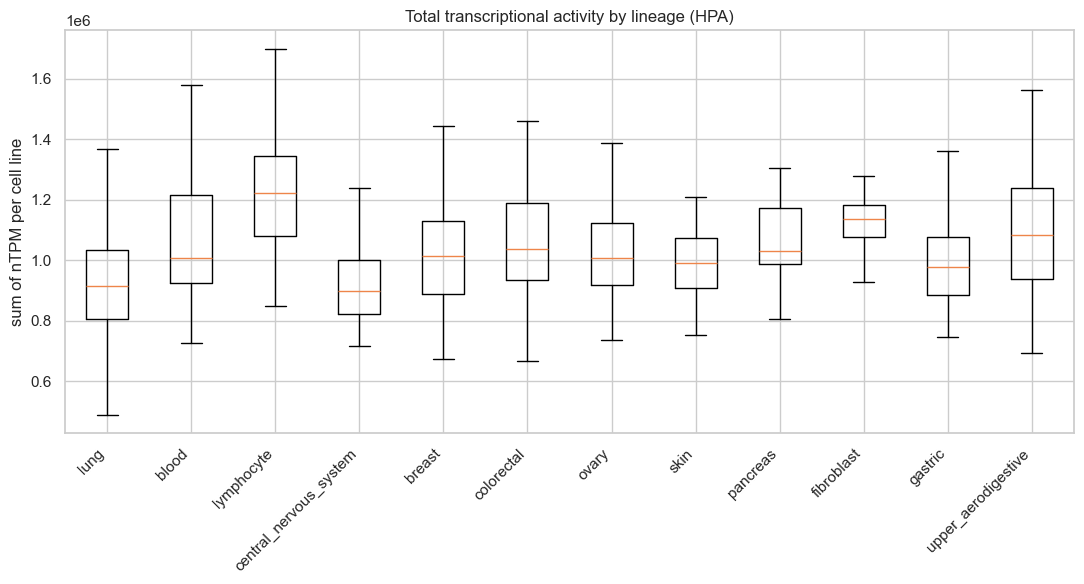

mapped to a lineage: 1112 / 1206 HPA cell lines


In [29]:
import __init__ as ini
d11 = pd.read_csv(ini.df11, sep="\t", usecols=["Cell line","Cellosaurus ID"])
d9  = pd.read_csv(ini.df9,  usecols=["RRID","lineage"])
name2lin = (d11.merge(d9, left_on="Cellosaurus ID", right_on="RRID", how="left")
              .dropna(subset=["Cell line"]).drop_duplicates("Cell line").set_index("Cell line")["lineage"])
ls = line_stats.copy()
ls["lineage"] = ls["Cell line"].map(name2lin)
top = ls["lineage"].value_counts().head(12).index
fig, ax = plt.subplots(figsize=(11,6))
ax.boxplot([ls[ls.lineage==l]["sum"].values for l in top], labels=list(top), showfliers=False)
plt.xticks(rotation=45, ha="right")
ax.set_ylabel("sum of nTPM per cell line"); ax.set_title("Total transcriptional activity by lineage (HPA)")
plt.tight_layout(); plt.show()
print("mapped to a lineage:", ls["lineage"].notna().sum(), "/", len(ls), "HPA cell lines")

## In Plain English — What This Dataset Means & Where It Goes Next

### 1. What this data actually is (layman terms)
Think of every gene as a **volume dial** inside a cell, and this file as a giant readout of how loud each dial is turned up, measured across 1,206 different lab-grown cancer cell lines (i.e., immortal cell populations grown in dishes for experiments). It comes from the **Human Protein Atlas (HPA)**. The number we care about, `nTPM`, is just *"how much of this gene's message the cell is actively making"* — high means the gene is switched on, near-zero means it's switched off. So this dataset tells us **which genes each cell line is using and how strongly**, which is exactly the kind of fingerprint we need to match against a researcher's "include / exclude these genes" request.

### 2. What we found, and the next steps (preprocessing + missing EDA)
What the notebook showed:
- It's in **long format**: 24.3 million rows, where each row is one (gene, cell line) pair. That's awkward for a model — models want one row per cell line.
- There are **20,162 genes × 1,206 cell lines**. About **27% of the values are exactly 0**, and that 0 is *real* ("gene is off"), not missing data.
- **10 gene names map to more than one Ensembl ID** (Ensembl ID = the gene's permanent barcode). Names are ambiguous; barcodes are not.
- Cell lines are named as free text (e.g., "143B"), so reaching the master catalogue (DepMap) needs a 3-step name translation, and we lose ~8.5% along the way (1,103 of 1,206 survive).

Next steps (preprocessing):
- **Pivot long → wide**: reshape to one row per cell line, one column per gene.
- **Use the `Gene` Ensembl barcode as the column key, not `Gene name`** — avoids the 10 collisions.
- **Keep `nTPM`** (the normalized value) and drop `TPM`/`pTPM` (they're >0.99 correlated — redundant).
- **Keep zeros as real zeros** (do not treat as missing / do not impute).
- **Translate cell-line names → Cellosaurus → DepMap** so this file can line up with all the others.

Still missing in EDA:
- A direct **gene-and-cell-line overlap check against the DepMap RNA file (df2)** to decide which of the two expression sources should be the "master" expression layer (they likely overlap heavily — we shouldn't double-count).

### 3. Which ML approach fits this dataset
**Unsupervised**, as a **feature source**. There's no built-in "right answer" column here — it's raw measurements. These gene dials become the input features that the ranking model reads when matching include/exclude genes, and unsupervised tools (clustering, PCA) are useful to confirm that cell lines of the same tissue naturally group together (a sanity check that the signal is real).

> **Big-picture note:** The DepMap master catalogue (`DepMap_ID` / `ModelID`) is the spine that every dataset joins onto. The model ultimately trains on the ~1,400 cell lines that have the core layers; this HPA expression file is one of the expression contributors to that spine.